In [331]:
import pandas as pd
import numpy as np

In [332]:
funds = pd.read_csv("../data/raw/02_nav_history.csv")

In [333]:
funds["date"] = pd.to_datetime(funds["date"])

In [334]:
funds = funds.sort_values(["amfi_code","date"])

In [335]:
funds["daily_return"] = (
    funds.groupby("amfi_code")["nav"]
.pct_change()
)

In [336]:
funds = funds.dropna(subset=["daily_return"])

Why do we multiply returns instead of adding them?
Investment returns compound over time

In [337]:
annual_returns = (
    funds.groupby("amfi_code")["daily_return"]
    .apply(lambda x: ((1 + x.dropna()).prod() ** (252 / len(x.dropna()))) - 1)
    .reset_index(name = "annualised_return")
)

annual_returns.rename(
    columns = {"daily_return": "annualised_return"}, inplace = True
    
)

In [338]:
funds = funds.merge(annual_returns, on="amfi_code",how="left")

In [339]:
funds.to_csv("../data/processed/returns_computed.csv", index = False)

print(funds.head(10))

   amfi_code       date       nav  daily_return  annualised_return
0     100016 2022-01-04  515.0971     -0.010306           0.025435
1     100016 2022-01-05  521.7239      0.012865           0.025435
2     100016 2022-01-06  515.7880     -0.011377           0.025435
3     100016 2022-01-07  515.1639     -0.001210           0.025435
4     100016 2022-01-10  510.7136     -0.008639           0.025435
5     100016 2022-01-11  513.5542      0.005562           0.025435
6     100016 2022-01-12  512.3195     -0.002404           0.025435
7     100016 2022-01-13  510.2445     -0.004050           0.025435
8     100016 2022-01-14  514.3636      0.008073           0.025435
9     100016 2022-01-17  514.7627      0.000776           0.025435


In [340]:
def calculate_cagr(group, years):

    end_date = group["date"].max()

    start_date = end_date - pd.DateOffset(years=years)

    start_rows = group[group["date"] <= start_date]

    if start_rows.empty:
        return np.nan
    
    start_nav = start_rows.iloc[-1]["nav"]
    end_nav = group.iloc[-1]["nav"] 

    cagr = (end_nav / start_nav) ** (1/years) - 1

    return cagr

In [341]:
cagr_1y = (funds.groupby("amfi_code")
           .apply(lambda x: calculate_cagr(x,1))
           .reset_index(name="cagr_1y"))

cagr_3y = (funds.groupby("amfi_code")
           .apply(lambda x: calculate_cagr(x, 3))
           .reset_index(name="cagr_3y"))

cagr_5y = (funds.groupby("amfi_code")
           .apply(lambda x: calculate_cagr(x, 5))
           .reset_index(name="cagr_5y"))

In [342]:
cagr = cagr_1y.merge(cagr_3y, on= "amfi_code")

cagr = cagr.merge(cagr_5y, on= "amfi_code")

In [343]:
print(cagr)

    amfi_code   cagr_1y   cagr_3y  cagr_5y
0      100016 -0.022243  0.012926      NaN
1      100025  0.037050  0.039164      NaN
2      100033  0.532324  0.324425      NaN
3      101206  0.479241  0.289677      NaN
4      101207 -0.239860 -0.041524      NaN
5      101208  0.072366  0.063158      NaN
6      102885  0.202077  0.196673      NaN
7      102886 -0.167975 -0.007674      NaN
8      102887  0.135831  0.255562      NaN
9      118632  0.339810  0.226524      NaN
10     118633  0.255400  0.210900      NaN
11     118634  0.158112  0.080079      NaN
12     118635  0.224932  0.200082      NaN
13     118636  0.104549  0.040622      NaN
14     119092  0.016091  0.005259      NaN
15     119093  0.197667  0.208168      NaN
16     119094  0.222611  0.351118      NaN
17     119095 -0.427976 -0.117058      NaN
18     119120  0.055220  0.058404      NaN
19     119551  0.604373  0.304565      NaN
20     119552  0.057061  0.162674      NaN
21     119598  0.827761  0.266699      NaN
22     1195

In [344]:
cagr.to_csv("../data/processed/cagr_report.csv")

In [345]:
volatility = (
    funds.groupby("amfi_code")["daily_return"]
    .std() * np.sqrt(252)
).reset_index(name="annualised_volatility")

In [346]:
sharpe = annual_returns.merge( volatility, on="amfi_code")

In [347]:
risk_free_rate = 0.065

In [348]:
sharpe["sharpe_ratio"] = (
    (sharpe["annualised_return"] - risk_free_rate) / sharpe["annualised_volatility"]
)

In [349]:
sharpe.to_csv(
    "../data/processed/sharpe_values.csv", index = False
)

In [350]:
neg_returns = funds.copy()

neg_returns["downside_return"] = (
    neg_returns["daily_return"]
    .where(neg_returns["daily_return"] < 0)
)

In [351]:
downside_volatility = (
    neg_returns.groupby("amfi_code")["downside_return"]
    .std()
    .mul(np.sqrt(252))
    .reset_index(name="downside_volatility")
)

In [352]:
sortino = annual_returns.merge(
    downside_volatility, on = "amfi_code", how = "left"
)

In [353]:
sortino["sortino_ratio"] = (
    (sortino["annualised_return"] - risk_free_rate) / sortino["downside_volatility"]
)

In [354]:
sortino.to_csv("../data/processed/sortino_values.csv")

In [355]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [356]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [357]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values(["index_name", "date"])

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"].pct_change()
)

In [358]:
merge_with_funds = funds.merge(
    benchmark[["date", "benchmark_return"]],on = "date",how = "inner"
)

In [359]:
merge_with_funds.head()

,amfi_code,date,nav,daily_return,annualised_return,benchmark_return
0,100016,2022-01-04,515.0971,-0.010306,0.025435,0.019783
1,100016,2022-01-04,515.0971,-0.010306,0.025435,0.001516
2,100016,2022-01-04,515.0971,-0.010306,0.025435,0.000044
3,100016,2022-01-04,515.0971,-0.010306,0.025435,-0.013540
4,100016,2022-01-04,515.0971,-0.010306,0.025435,0.011253


In [360]:
from scipy.stats import linregress

In [361]:
def calc_alpha_beta(group):

    group = group.dropna(subset=["daily_return", "benchmark_return"])

    if len(group) < 2:
        return pd.Series({"alpha": np.nan, "beta": np.nan})
    
    regression = linregress(
        group["benchmark_return"],group["daily_return"]
    )

    beta = regression.slope

    alpha = regression.slope

    alpha = regression.intercept * 252

    return pd.Series({
        "alpha": alpha, "beta": beta
    })

In [362]:
alpha_beta = (
    merge_with_funds.groupby("amfi_code")
          .apply(calc_alpha_beta)
          .reset_index()
)

In [363]:
alpha_beta.to_csv("../data/processed/alpha_beta.csv", index=False)

In [364]:
funds["max"] = (funds.groupby("amfi_code")["nav"].cummax())

In [365]:
funds["drawdown"] = (funds["nav"] / funds["max"] - 1)

In [366]:
max_drawdown = (funds.groupby("amfi_code")["drawdown"].min()
                .reset_index(name="max_drawdown"))

In [367]:
max_drawdown.to_csv("../data/processed/max_drawdown.csv",index = False)

In [368]:
cagr = pd.read_csv("../data/processed/cagr_report.csv")
sharpe = pd.read_csv("../data/processed/sharpe_values.csv")
alpha_beta = pd.read_csv("../data/processed/alpha_beta.csv")
max_dd = pd.read_csv("../data/processed/max_drawdown.csv")
master = pd.read_csv("../data/raw/01_fund_master.csv")

In [369]:
master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [370]:
scorecard = (
    cagr
    .merge(sharpe[["amfi_code", "sharpe_ratio"]], on="amfi_code")
    .merge(alpha_beta[["amfi_code", "alpha"]], on="amfi_code")
    .merge(max_dd, on="amfi_code")
    .merge(master[["amfi_code", "expense_ratio_pct"]], on="amfi_code")
)

In [371]:
scorecard["cagr_rank"] = scorecard["cagr_1y"].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)

scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)

In [372]:
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(ascending=False)

In [373]:
scorecard["score"] = (0.30 * scorecard["cagr_rank"]
                      + 0.25 * scorecard["sharpe_rank"]
                      + 0.20 * scorecard["alpha_rank"]
                      + 0.15 * scorecard["expense_rank"]
                      + 0.10 * scorecard["drawdown_rank"])

In [374]:
scorecard = scorecard.sort_values("score")
scorecard["overall_rank"] = range(1, len(scorecard) + 1)

In [375]:
scorecard.to_csv("../data/processed/fund_scorecard.csv", index = False)

In [376]:
funds["date"] = pd.to_datetime(funds["date"])
end_date = funds["date"].max()
start_date = end_date - pd.DateOffset(years=3)
fund_3y = funds[funds["date"] >= start_date]


In [377]:
benchmark["date"] = pd.to_datetime(benchmark["date"])
benchmark_3y = benchmark[benchmark["date"] >= start_date]

In [378]:
benchmark_3y = benchmark_3y[benchmark_3y["index_name"].isin(["NIFTY 50","NIFTY 100"])]

In [379]:
benchmark["index_name"].unique()

<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str

In [380]:
top5 = scorecard.nsmallest(5, "overall_rank")["amfi_code"]

top_funds = fund_3y[
    fund_3y["amfi_code"].isin(top5)
]

In [381]:
top_funds["normalized_nav"] = (
    top_funds.groupby("amfi_code")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [382]:
benchmark_3y["normalized_index"] = (
    benchmark_3y.groupby("index_name")["close_value"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [383]:
import matplotlib.pyplot as plt

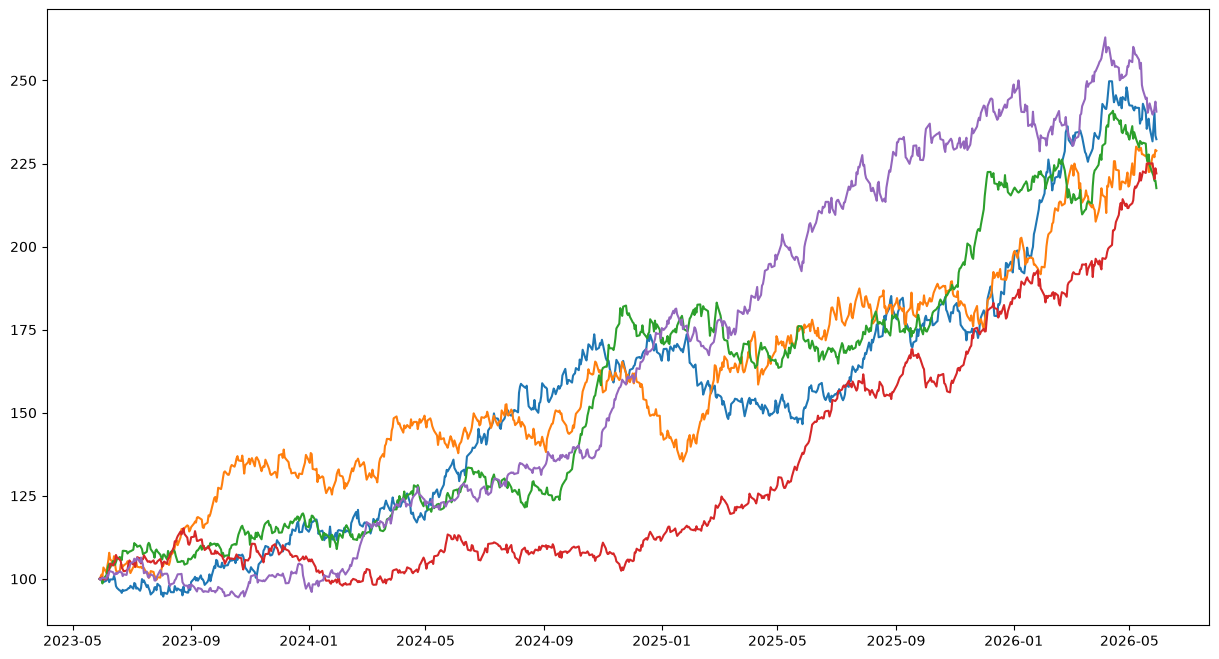

In [384]:
plt.figure(figsize=(15,8))

for code in top5:
    data = top_funds[top_funds["amfi_code"] == code]

    plt.plot(data["date"], data["normalized_nav"], label=f"Fund {code}")

C:\Users\730kh\AppData\Local\Temp\ipykernel_31100\1244974527.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


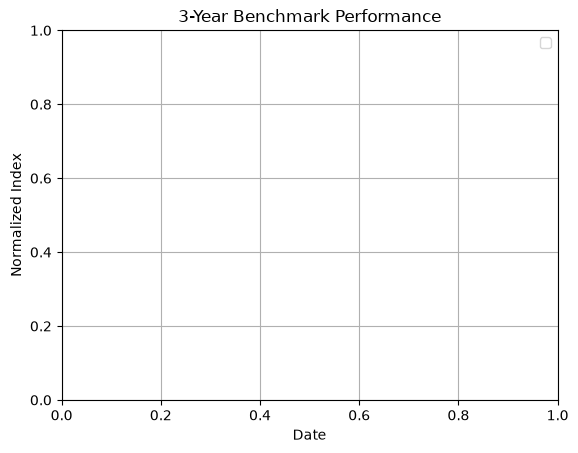

In [388]:
for index in benchmark_3y["index_name"].unique():
    bench_data = benchmark_3y[benchmark_3y["index_name"] == index]

    plt.plot(
    data["date"],
    data["normalized_index"],
    label=index,
    linewidth=3,
    linestyle="--"
    )

plt.legend()
plt.xlabel("Date")
plt.ylabel("Normalized Index")
plt.title("3-Year Benchmark Performance")
plt.grid(True)
plt.show()

In [389]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

In [390]:
print(benchmark["index_name"].unique())

<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str


In [391]:
tracking = funds.merge(
    nifty50[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

In [392]:
tracking.head()

,amfi_code,date,nav,daily_return,annualised_return,max,drawdown,benchmark_return
0,100016,2022-01-04,515.0971,-0.010306,0.025435,515.0971,0.000000,0.011253
1,100016,2022-01-05,521.7239,0.012865,0.025435,521.7239,0.000000,0.008220
2,100016,2022-01-06,515.7880,-0.011377,0.025435,521.7239,-0.011377,0.002437
3,100016,2022-01-07,515.1639,-0.001210,0.025435,521.7239,-0.012574,-0.006676
4,100016,2022-01-10,510.7136,-0.008639,0.025435,521.7239,-0.021104,0.020592


In [393]:
import numpy as np

tracking_error = (
    tracking.groupby("amfi_code")
    .apply(
        lambda x: np.std(
            x["daily_return"] - x["benchmark_return"],
            ddof=1
        ) * np.sqrt(252)
    )
    .reset_index(name="tracking_error")
)

In [395]:
tracking_error.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)